In [1]:
"""
Fragment 1 — Data Loading & Feature Extraction (Flattened Pixels)
==================================================================
KNN Binary Mould Classification Pipeline — Mold vs No Mold

- Loads train, val and test data from disk
- Resizes all images to IMG_SIZE
- Flattens each image to a 1D feature vector
- Normalises pixel values to [0, 1]
- Train data loaded from augmented folder
- Test data not touched until Fragment 2 evaluation
- Binary labels: 0 / 1
"""

import os
import numpy as np
from pathlib import Path
from PIL import Image
from sklearn.preprocessing import LabelEncoder

# ── Configuration ─────────────────────────────────────────────────────────────

DATA_DIR   = r"D:\Mold Studies Binary\Mould Binary Classification"
AUG_DIR    = os.path.join(DATA_DIR, "augmented")
VALID_DIR  = os.path.join(DATA_DIR, "val")
TEST_DIR   = os.path.join(DATA_DIR, "test")

IMG_SIZE   = (16, 16)     # kept same as SVM for fair comparison
IMG_EXTS   = {".jpg", ".jpeg", ".png", ".bmp", ".tiff", ".webp"}

# ── Step 1: Image loader ──────────────────────────────────────────────────────

def load_flat_dataset(folder: str, img_size: tuple) -> tuple:
    """
    Loads all images from a class-structured folder.
    Resizes, flattens and normalises each image.
    Returns X (n_samples, n_features) and y (n_samples,) as strings.
    """
    X, y = [], []

    folder_path = Path(folder)
    classes     = sorted([d.name for d in folder_path.iterdir() if d.is_dir()])

    for cls in classes:
        cls_path = folder_path / cls
        images   = [
            f for f in cls_path.iterdir()
            if f.suffix.lower() in IMG_EXTS
        ]

        for img_path in images:
            try:
                img = Image.open(img_path).convert("RGB")
                img = img.resize(img_size)
                arr = np.array(img, dtype=np.float32) / 255.0
                X.append(arr.flatten())
                y.append(cls)
            except Exception as e:
                print(f"  ⚠️  Skipped {img_path.name}: {e}")

    return np.array(X), np.array(y)

# ── Step 2: Load all three sets ───────────────────────────────────────────────

print("=" * 60)
print("  Fragment 1 — Loading & Flattening Images")
print("=" * 60)
print(f"  Pipeline      : Binary — Mold vs No Mold")
print(f"  Image size    : {IMG_SIZE}")
print(f"  Features      : {IMG_SIZE[0] * IMG_SIZE[1] * 3}")
print("=" * 60)

print(f"\n  Loading train (augmented)...")
X_train_raw, y_train_raw = load_flat_dataset(AUG_DIR,   IMG_SIZE)
print(f"  ✓ Train : {X_train_raw.shape}")

print(f"\n  Loading val...")
X_val_raw,   y_val_raw   = load_flat_dataset(VALID_DIR, IMG_SIZE)
print(f"  ✓ Val   : {X_val_raw.shape}")

print(f"\n  Loading test...")
X_test_raw,  y_test_raw  = load_flat_dataset(TEST_DIR,  IMG_SIZE)
print(f"  ✓ Test  : {X_test_raw.shape}")

# ── Step 3: Encode labels ─────────────────────────────────────────────────────

label_encoder = LabelEncoder()
label_encoder.fit(y_train_raw)

y_train = label_encoder.transform(y_train_raw)
y_val   = label_encoder.transform(y_val_raw)
y_test  = label_encoder.transform(y_test_raw)

CLASS_NAMES = list(label_encoder.classes_)
NUM_CLASSES = len(CLASS_NAMES)

# ── Step 4: Summary ───────────────────────────────────────────────────────────

print("\n" + "=" * 60)
print("  Fragment 1 — Data Ready")
print("=" * 60)
print(f"  Pipeline      : Binary — Mold vs No Mold")
print(f"  Architecture  : KNN (flattened pixels)")
print(f"  Train samples : {X_train_raw.shape[0]}")
print(f"  Val samples   : {X_val_raw.shape[0]}")
print(f"  Test samples  : {X_test_raw.shape[0]}")
print(f"  Features      : {X_train_raw.shape[1]}")
print(f"  Classes       : {CLASS_NAMES}")
print(f"  Class indices : {dict(zip(CLASS_NAMES, label_encoder.transform(CLASS_NAMES)))}")
print("=" * 60)

print("\n  ✓ Fragment 1 complete.")
print("     Proceed to Fragment 2 — KNN Training & 5-Run Analysis.\n")

  Fragment 1 — Loading & Flattening Images
  Pipeline      : Binary — Mold vs No Mold
  Image size    : (16, 16)
  Features      : 768

  Loading train (augmented)...
  ✓ Train : (51838, 768)

  Loading val...
  ✓ Val   : (648, 768)

  Loading test...
  ✓ Test  : (649, 768)

  Fragment 1 — Data Ready
  Pipeline      : Binary — Mold vs No Mold
  Architecture  : KNN (flattened pixels)
  Train samples : 51838
  Val samples   : 648
  Test samples  : 649
  Features      : 768
  Classes       : ['Mold', 'No mold']
  Class indices : {'Mold': 0, 'No mold': 1}

  ✓ Fragment 1 complete.
     Proceed to Fragment 2 — KNN Training & 5-Run Analysis.



  Fragment 2 — KNN Binary 5-Run Training
  Pipeline     : Binary — Mold vs No Mold
  N Neighbours : 5
  Metric       : euclidean
  Weights      : distance
  Threshold    : 0.5
  Seeds        : [27, 42, 99, 123, 256]
  Features     : 768

  RUN 1 / 5  —  KNN Binary
  Seed : 27

  Training KNN...
  ✓ Training complete
  Predicting...

  Run 1 Results
    Accuracy     : 0.9384
    Precision    : 0.9323
    Sensitivity  : 0.9624
    Specificity  : 0.9061
    F1 Score     : 0.9471
    AUC          : 0.9746
    TP=358  TN=251  FP=26  FN=14


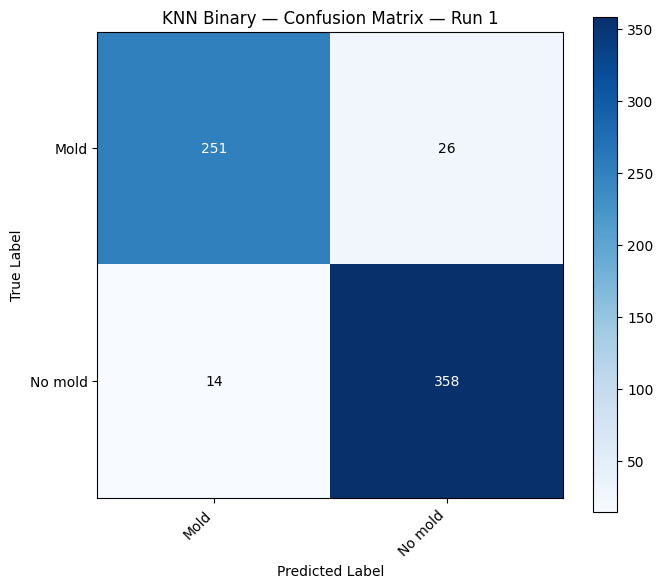

  Saved: D:\Mold Studies Binary\Models\plots\knn_flat_binary\knn_flat_binary_confusion_matrix_run1.png


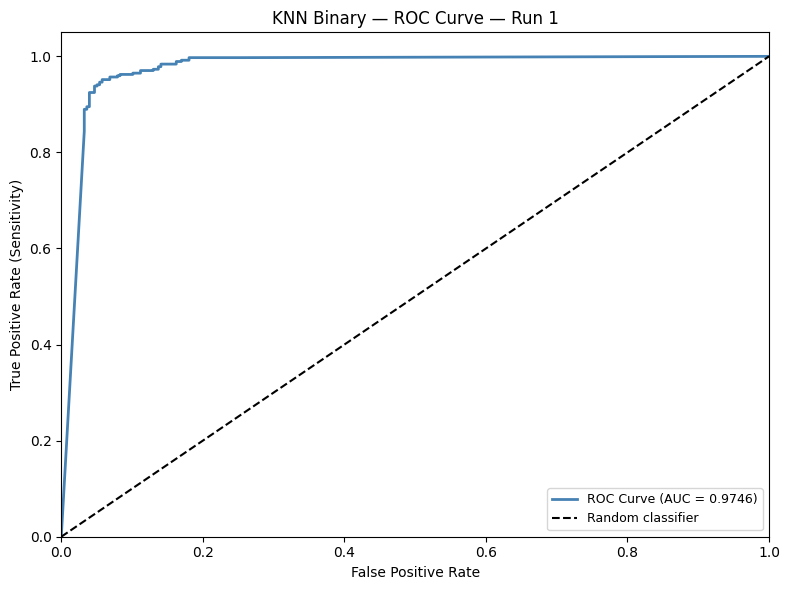

  Saved: D:\Mold Studies Binary\Models\plots\knn_flat_binary\knn_flat_binary_roc_curve_run1.png


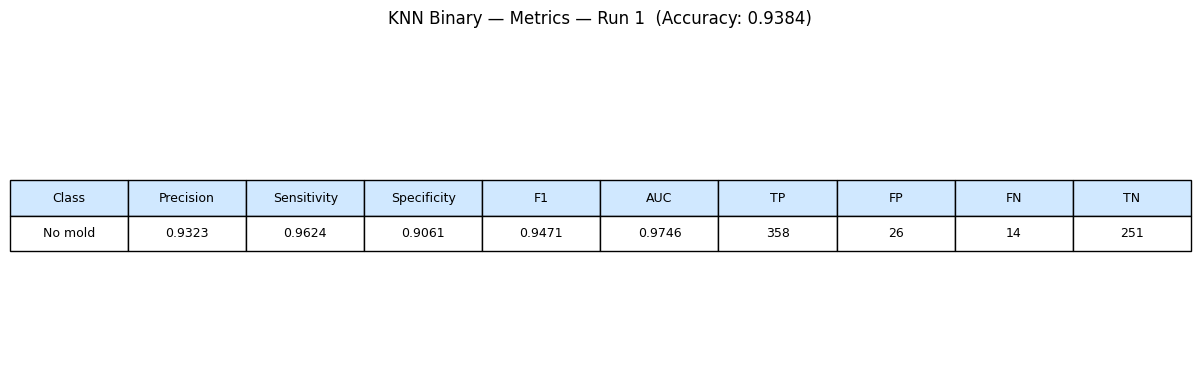

  Saved: D:\Mold Studies Binary\Models\plots\knn_flat_binary\knn_flat_binary_metrics_table_run1.png

  RUN 2 / 5  —  KNN Binary
  Seed : 42

  Training KNN...
  ✓ Training complete
  Predicting...

  Run 2 Results
    Accuracy     : 0.9384
    Precision    : 0.9323
    Sensitivity  : 0.9624
    Specificity  : 0.9061
    F1 Score     : 0.9471
    AUC          : 0.9746
    TP=358  TN=251  FP=26  FN=14


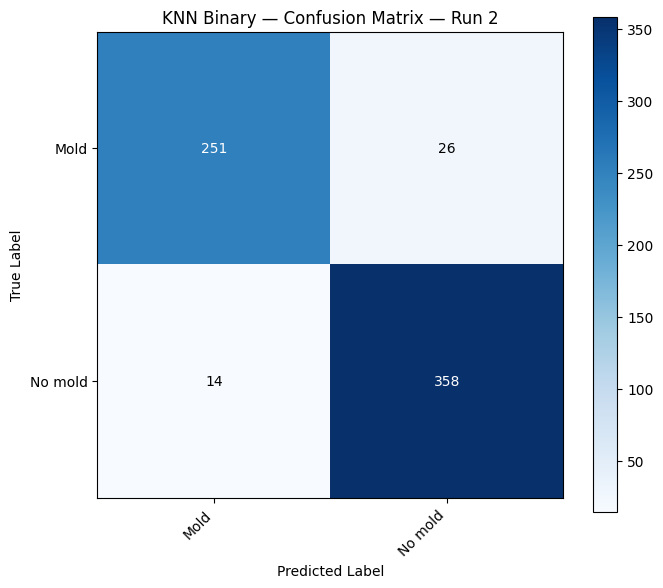

  Saved: D:\Mold Studies Binary\Models\plots\knn_flat_binary\knn_flat_binary_confusion_matrix_run2.png


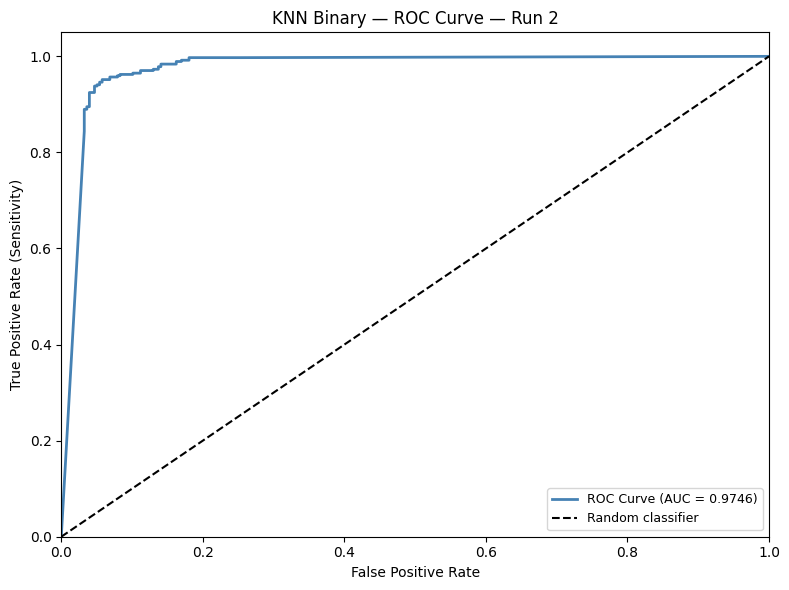

  Saved: D:\Mold Studies Binary\Models\plots\knn_flat_binary\knn_flat_binary_roc_curve_run2.png


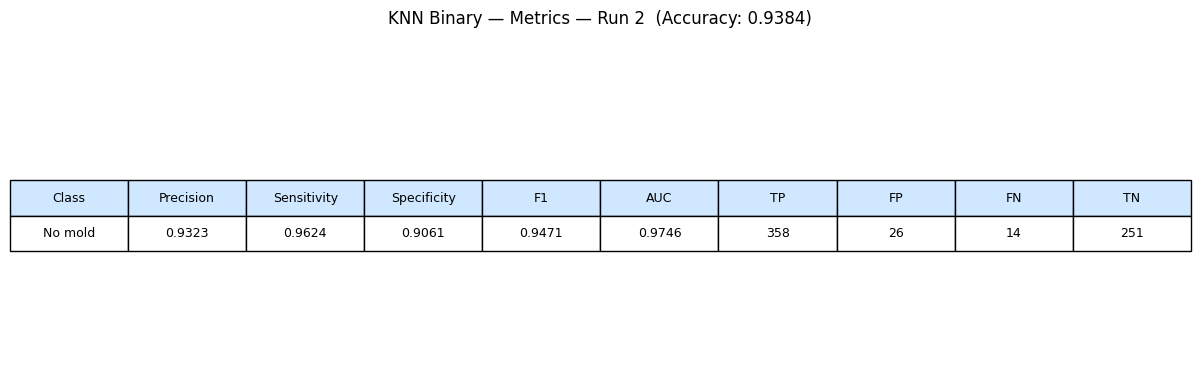

  Saved: D:\Mold Studies Binary\Models\plots\knn_flat_binary\knn_flat_binary_metrics_table_run2.png

  RUN 3 / 5  —  KNN Binary
  Seed : 99

  Training KNN...
  ✓ Training complete
  Predicting...

  Run 3 Results
    Accuracy     : 0.9384
    Precision    : 0.9323
    Sensitivity  : 0.9624
    Specificity  : 0.9061
    F1 Score     : 0.9471
    AUC          : 0.9746
    TP=358  TN=251  FP=26  FN=14


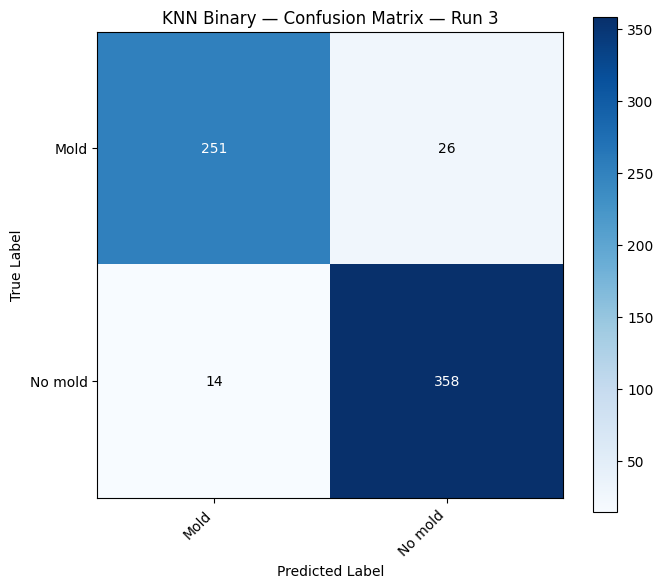

  Saved: D:\Mold Studies Binary\Models\plots\knn_flat_binary\knn_flat_binary_confusion_matrix_run3.png


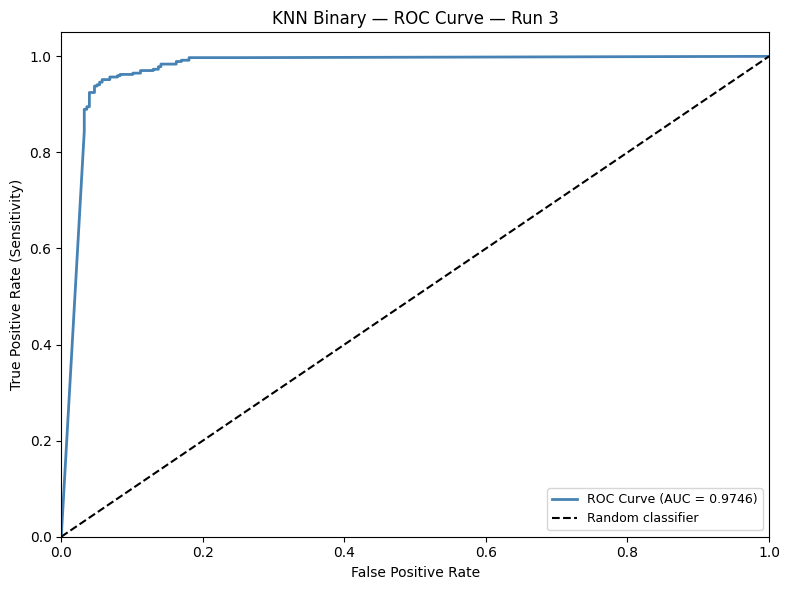

  Saved: D:\Mold Studies Binary\Models\plots\knn_flat_binary\knn_flat_binary_roc_curve_run3.png


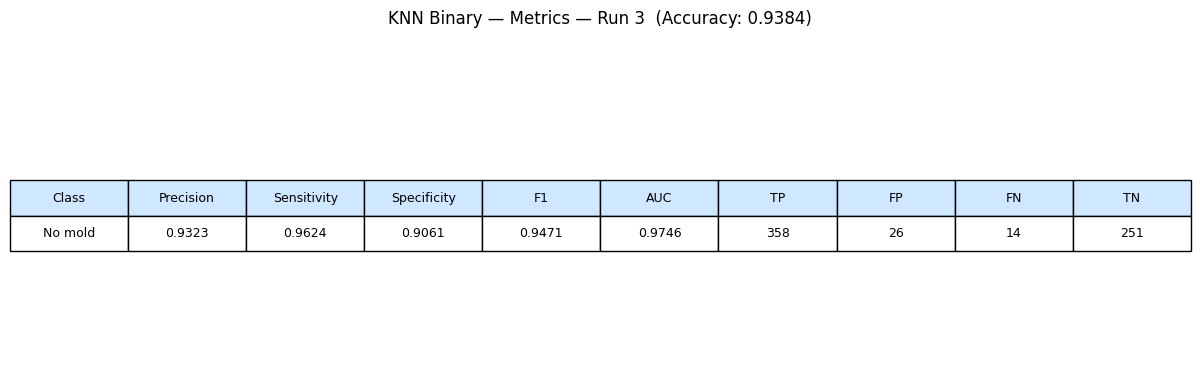

  Saved: D:\Mold Studies Binary\Models\plots\knn_flat_binary\knn_flat_binary_metrics_table_run3.png

  RUN 4 / 5  —  KNN Binary
  Seed : 123

  Training KNN...
  ✓ Training complete
  Predicting...

  Run 4 Results
    Accuracy     : 0.9384
    Precision    : 0.9323
    Sensitivity  : 0.9624
    Specificity  : 0.9061
    F1 Score     : 0.9471
    AUC          : 0.9746
    TP=358  TN=251  FP=26  FN=14


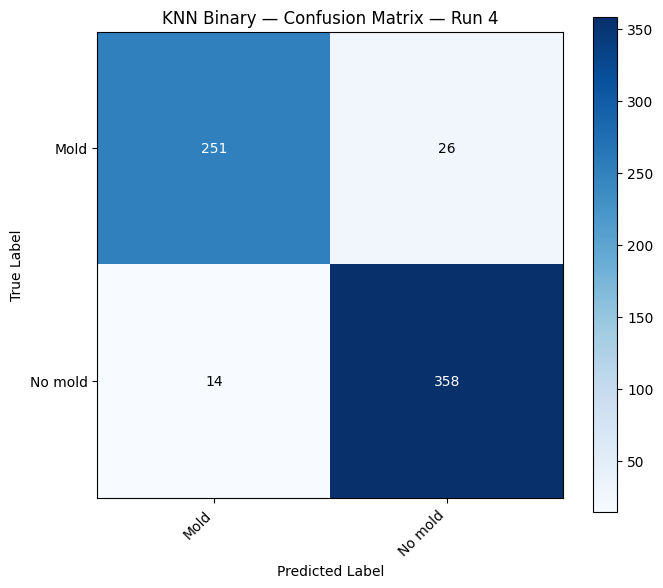

  Saved: D:\Mold Studies Binary\Models\plots\knn_flat_binary\knn_flat_binary_confusion_matrix_run4.png


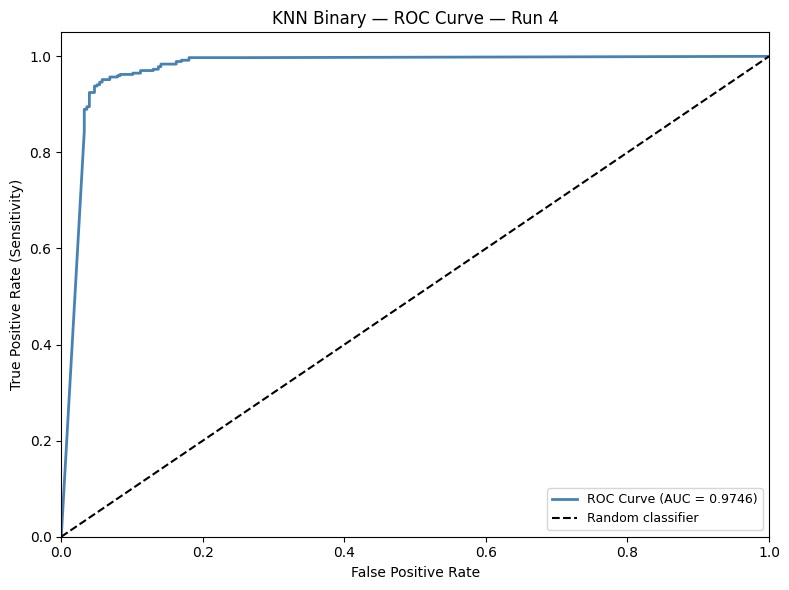

  Saved: D:\Mold Studies Binary\Models\plots\knn_flat_binary\knn_flat_binary_roc_curve_run4.png


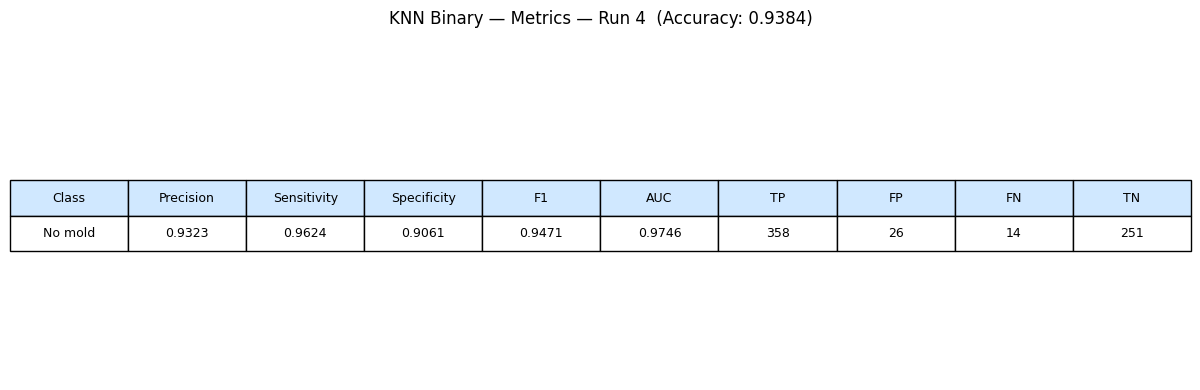

  Saved: D:\Mold Studies Binary\Models\plots\knn_flat_binary\knn_flat_binary_metrics_table_run4.png

  RUN 5 / 5  —  KNN Binary
  Seed : 256

  Training KNN...
  ✓ Training complete
  Predicting...

  Run 5 Results
    Accuracy     : 0.9384
    Precision    : 0.9323
    Sensitivity  : 0.9624
    Specificity  : 0.9061
    F1 Score     : 0.9471
    AUC          : 0.9746
    TP=358  TN=251  FP=26  FN=14


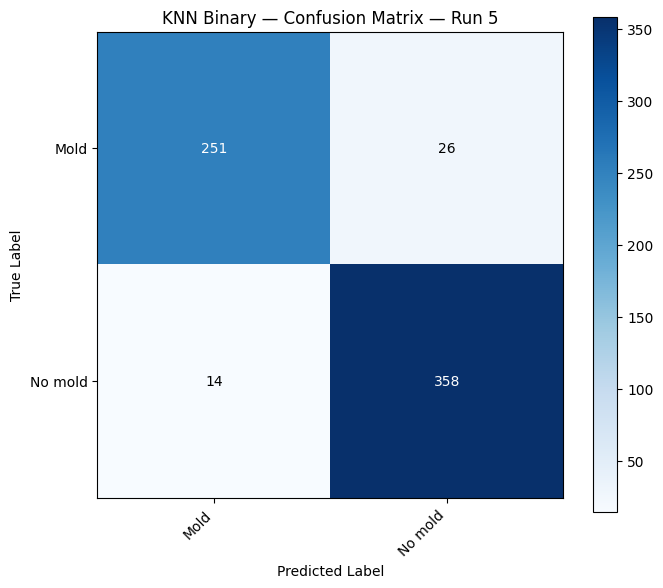

  Saved: D:\Mold Studies Binary\Models\plots\knn_flat_binary\knn_flat_binary_confusion_matrix_run5.png


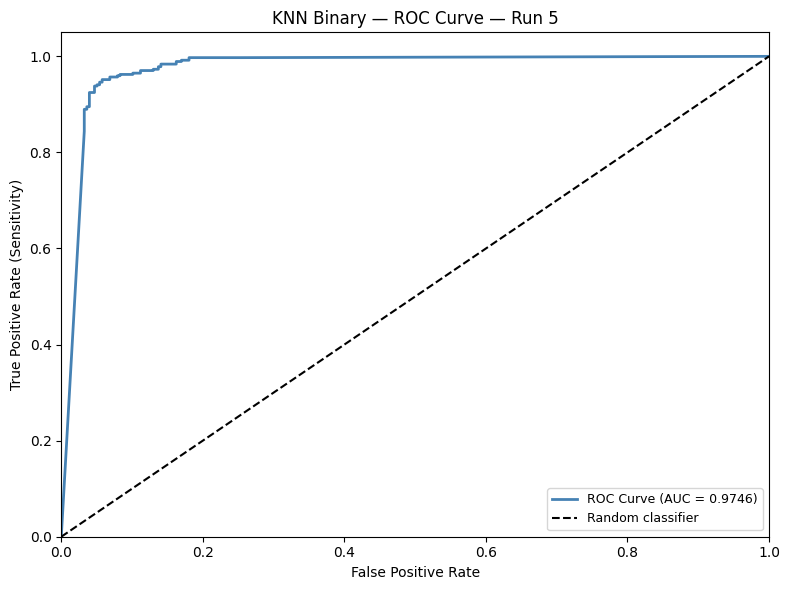

  Saved: D:\Mold Studies Binary\Models\plots\knn_flat_binary\knn_flat_binary_roc_curve_run5.png


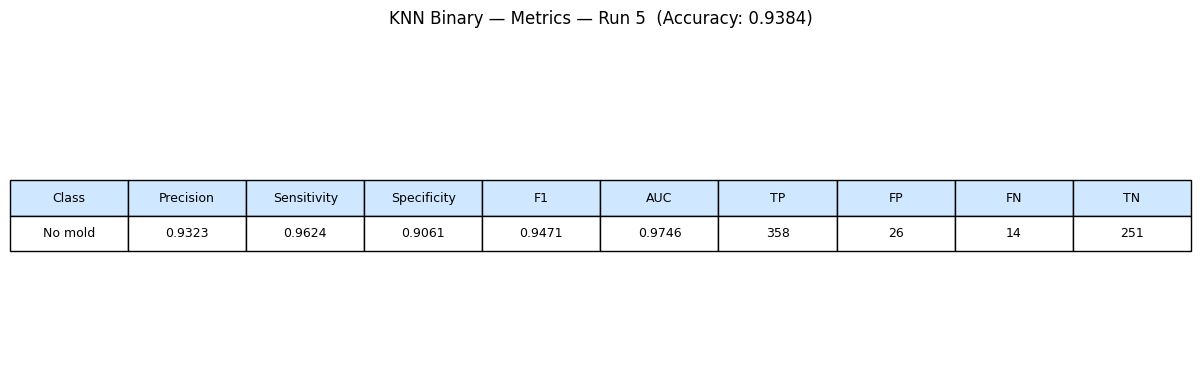

  Saved: D:\Mold Studies Binary\Models\plots\knn_flat_binary\knn_flat_binary_metrics_table_run5.png

  PER-RUN RESULTS — KNN Binary (Flattened Pixels)
  Run       Seed    Accuracy   Precision   Sensitivity   Specificity  F1 Score       AUC
──────────────────────────────────────────────────────────────────────────────────────────────
  1           27      0.9384      0.9323        0.9624        0.9061    0.9471    0.9746
  2           42      0.9384      0.9323        0.9624        0.9061    0.9471    0.9746
  3           99      0.9384      0.9323        0.9624        0.9061    0.9471    0.9746
  4          123      0.9384      0.9323        0.9624        0.9061    0.9471    0.9746
  5          256      0.9384      0.9323        0.9624        0.9061    0.9471    0.9746
──────────────────────────────────────────────────────────────────────────────────────────────

────────────────────────────  Statistical Summary  ────────────────────────────
  Metric              Mean       Std       M

c:\Users\HomePC\miniconda3\envs\tf-cpu\lib\site-packages\scipy\stats\_distn_infrastructure.py:2304: RuntimeWarning: invalid value encountered in multiply
  lower_bound = _a * scale + loc
c:\Users\HomePC\miniconda3\envs\tf-cpu\lib\site-packages\scipy\stats\_distn_infrastructure.py:2305: RuntimeWarning: invalid value encountered in multiply
  upper_bound = _b * scale + loc


In [2]:
"""
Fragment 2 — KNN Training, 5-Run Statistical Analysis & Evaluation
===================================================================
KNN Binary Mould Classification Pipeline — Mold vs No Mold

- Trains KNN 5 times using different random seeds
- Each run shuffles train data differently before fitting
- Computes full binary metrics per run on test set
- Computes confidence intervals across 5 runs
- Saves results for cross-model comparison
"""

import os
import numpy as np
import matplotlib.pyplot as plt
from sklearn.neighbors import KNeighborsClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    confusion_matrix,
    roc_curve,
    auc,
)
import scipy.stats as stats

# ── Configuration ─────────────────────────────────────────────────────────────

SAVE_DIR   = r"D:\Mold Studies Binary\Models"
PLOT_DIR   = os.path.join(SAVE_DIR, "plots", "knn_flat_binary")
TOTAL_RUNS = 5
SEEDS      = [27, 42, 99, 123, 256]

os.makedirs(SAVE_DIR, exist_ok=True)
os.makedirs(PLOT_DIR, exist_ok=True)

# ── KNN Parameters ────────────────────────────────────────────────────────────

KNN_N_NEIGHBORS = 5
KNN_METRIC      = "euclidean"
KNN_WEIGHTS     = "distance"

THRESHOLD       = 0.5

# ── Step 1: Helper Functions ──────────────────────────────────────────────────

def compute_metrics_binary(y_true, y_pred, y_prob):
    """
    Computes full binary evaluation metrics.
    y_prob is the probability for the positive class (column 1).
    """
    cm = confusion_matrix(y_true, y_pred)
    tn, fp, fn, tp = cm.ravel()

    precision   = tp / (tp + fp + 1e-7)
    recall      = tp / (tp + fn + 1e-7)
    specificity = tn / (tn + fp + 1e-7)
    f1          = 2 * precision * recall / (precision + recall + 1e-7)
    accuracy    = (tp + tn) / (tp + tn + fp + fn + 1e-7)

    fpr, tpr, _ = roc_curve(y_true, y_prob)
    roc_auc     = auc(fpr, tpr)

    return {
        "cm"         : cm,
        "tp"         : int(tp),
        "tn"         : int(tn),
        "fp"         : int(fp),
        "fn"         : int(fn),
        "accuracy"   : accuracy,
        "precision"  : precision,
        "recall"     : recall,
        "specificity": specificity,
        "f1"         : f1,
        "fpr"        : fpr,
        "tpr"        : tpr,
        "auc"        : roc_auc,
    }


def plot_confusion_matrix(cm, run_idx, save_dir):
    fig, ax = plt.subplots(figsize=(7, 6))
    im = ax.imshow(cm, interpolation="nearest", cmap=plt.cm.Blues)
    plt.colorbar(im, ax=ax)
    ax.set(
        xticks      = np.arange(NUM_CLASSES),
        yticks      = np.arange(NUM_CLASSES),
        xticklabels = CLASS_NAMES,
        yticklabels = CLASS_NAMES,
        title       = f"KNN Binary — Confusion Matrix — Run {run_idx}",
        ylabel      = "True Label",
        xlabel      = "Predicted Label",
    )
    plt.setp(ax.get_xticklabels(), rotation=45, ha="right")
    thresh = cm.max() / 2.0
    for i in range(NUM_CLASSES):
        for j in range(NUM_CLASSES):
            ax.text(j, i, format(cm[i, j], "d"),
                    ha="center", va="center",
                    color="white" if cm[i, j] > thresh else "black")
    plt.tight_layout()
    path = os.path.join(save_dir,
                        f"knn_flat_binary_confusion_matrix_run{run_idx}.png")
    plt.savefig(path, dpi=150)
    plt.show()
    plt.close()
    print(f"  Saved: {path}")


def plot_roc_curve(metrics, run_idx, save_dir):
    fig, ax = plt.subplots(figsize=(8, 6))
    ax.plot(
        metrics["fpr"],
        metrics["tpr"],
        color = "steelblue",
        lw    = 2,
        label = f"ROC Curve (AUC = {metrics['auc']:.4f})"
    )
    ax.plot([0, 1], [0, 1], "k--", label="Random classifier")
    ax.set(
        title  = f"KNN Binary — ROC Curve — Run {run_idx}",
        xlabel = "False Positive Rate",
        ylabel = "True Positive Rate (Sensitivity)",
        xlim   = [0.0, 1.0],
        ylim   = [0.0, 1.05],
    )
    ax.legend(loc="lower right", fontsize=9)
    plt.tight_layout()
    path = os.path.join(save_dir,
                        f"knn_flat_binary_roc_curve_run{run_idx}.png")
    plt.savefig(path, dpi=150)
    plt.show()
    plt.close()
    print(f"  Saved: {path}")


def plot_metrics_table(metrics, run_idx, save_dir):
    fig, ax = plt.subplots(figsize=(12, 4))
    ax.axis("off")
    rows = [[
        CLASS_NAMES[1],
        f"{metrics['precision']:.4f}",
        f"{metrics['recall']:.4f}",
        f"{metrics['specificity']:.4f}",
        f"{metrics['f1']:.4f}",
        f"{metrics['auc']:.4f}",
        f"{metrics['tp']}",
        f"{metrics['fp']}",
        f"{metrics['fn']}",
        f"{metrics['tn']}",
    ]]
    col_labels = ["Class", "Precision", "Sensitivity",
                  "Specificity", "F1", "AUC",
                  "TP", "FP", "FN", "TN"]
    table = ax.table(
        cellText  = rows,
        colLabels = col_labels,
        loc       = "center",
        cellLoc   = "center",
    )
    table.auto_set_font_size(False)
    table.set_fontsize(9)
    table.scale(1.2, 2.0)
    for j in range(len(col_labels)):
        table[0, j].set_facecolor("#d0e8ff")
    ax.set_title(
        f"KNN Binary — Metrics — Run {run_idx}  "
        f"(Accuracy: {metrics['accuracy']:.4f})",
        fontsize=12, pad=20
    )
    plt.tight_layout()
    path = os.path.join(save_dir,
                        f"knn_flat_binary_metrics_table_run{run_idx}.png")
    plt.savefig(path, dpi=150, bbox_inches="tight")
    plt.show()
    plt.close()
    print(f"  Saved: {path}")

# ── Step 2: 5-Run Training Loop ───────────────────────────────────────────────

print("=" * 60)
print("  Fragment 2 — KNN Binary 5-Run Training")
print("=" * 60)
print(f"  Pipeline     : Binary — Mold vs No Mold")
print(f"  N Neighbours : {KNN_N_NEIGHBORS}")
print(f"  Metric       : {KNN_METRIC}")
print(f"  Weights      : {KNN_WEIGHTS}")
print(f"  Threshold    : {THRESHOLD}")
print(f"  Seeds        : {SEEDS}")
print(f"  Features     : {X_train_raw.shape[1]}")
print("=" * 60)

all_metrics     = []
all_run_results = []

for run_idx, seed in enumerate(SEEDS, 1):

    print(f"\n{'='*60}")
    print(f"  RUN {run_idx} / {TOTAL_RUNS}  —  KNN Binary")
    print(f"  Seed : {seed}")
    print(f"{'='*60}\n")

    # ── Shuffle train data with this run's seed ────────────────────────────────

    MAX_TRAIN = 3000
    rng     = np.random.RandomState(seed)
    indices = rng.permutation(len(X_train_raw))
    X_tr    = X_train_raw[indices]
    y_tr    = y_train[indices]

    # ── Scale features ─────────────────────────────────────────────────────────
    scaler  = StandardScaler()
    X_tr_sc = scaler.fit_transform(X_tr)
    X_te_sc = scaler.transform(X_test_raw)

    # ── Train KNN ──────────────────────────────────────────────────────────────
    print(f"  Training KNN...")
    knn = KNeighborsClassifier(
        n_neighbors = KNN_N_NEIGHBORS,
        metric      = KNN_METRIC,
        weights     = KNN_WEIGHTS,
        n_jobs      = -1,
    )
    knn.fit(X_tr_sc, y_tr)
    print(f"  ✓ Training complete")

    # ── Evaluate on test set ───────────────────────────────────────────────────
    print(f"  Predicting...")
    y_pred = knn.predict(X_te_sc)
    y_prob = knn.predict_proba(X_te_sc)[:, 1]   # probability of positive class

    metrics         = compute_metrics_binary(y_test, y_pred, y_prob)
    metrics["run"]  = run_idx
    metrics["seed"] = seed
    all_metrics.append(metrics)

    all_run_results.append({
        "run"        : run_idx,
        "seed"       : seed,
        "accuracy"   : metrics["accuracy"],
        "precision"  : metrics["precision"],
        "recall"     : metrics["recall"],
        "specificity": metrics["specificity"],
        "f1"         : metrics["f1"],
        "auc"        : metrics["auc"],
    })

    print(f"\n  Run {run_idx} Results")
    print(f"    Accuracy     : {metrics['accuracy']:.4f}")
    print(f"    Precision    : {metrics['precision']:.4f}")
    print(f"    Sensitivity  : {metrics['recall']:.4f}")
    print(f"    Specificity  : {metrics['specificity']:.4f}")
    print(f"    F1 Score     : {metrics['f1']:.4f}")
    print(f"    AUC          : {metrics['auc']:.4f}")
    print(f"    TP={metrics['tp']}  TN={metrics['tn']}  "
          f"FP={metrics['fp']}  FN={metrics['fn']}")

    plot_confusion_matrix(metrics["cm"],  run_idx, PLOT_DIR)
    plot_roc_curve(metrics,               run_idx, PLOT_DIR)
    plot_metrics_table(metrics,           run_idx, PLOT_DIR)

# ── Step 3: Per-Run Summary Table ─────────────────────────────────────────────

col_run  = 6
col_seed = 8
col_acc  = 12
col_prec = 12
col_sens = 14
col_spec = 14
col_f1   = 10
col_auc  = 10

divider = "=" * (col_run + col_seed + col_acc + col_prec +
                 col_sens + col_spec + col_f1 + col_auc + 8)
thin    = "─" * (col_run + col_seed + col_acc + col_prec +
                 col_sens + col_spec + col_f1 + col_auc + 8)

print(f"\n{divider}")
print("  PER-RUN RESULTS — KNN Binary (Flattened Pixels)")
print(divider)
print(
    f"  {'Run':<{col_run}}"
    f"{'Seed':>{col_seed}}"
    f"{'Accuracy':>{col_acc}}"
    f"{'Precision':>{col_prec}}"
    f"{'Sensitivity':>{col_sens}}"
    f"{'Specificity':>{col_spec}}"
    f"{'F1 Score':>{col_f1}}"
    f"{'AUC':>{col_auc}}"
)
print(thin)

for r in all_run_results:
    print(
        f"  {r['run']:<{col_run}}"
        f"{r['seed']:>{col_seed}}"
        f"{r['accuracy']:>{col_acc}.4f}"
        f"{r['precision']:>{col_prec}.4f}"
        f"{r['recall']:>{col_sens}.4f}"
        f"{r['specificity']:>{col_spec}.4f}"
        f"{r['f1']:>{col_f1}.4f}"
        f"{r['auc']:>{col_auc}.4f}"
    )

print(thin)

# ── Step 4: Statistical Summary with Confidence Intervals ─────────────────────

print(f"\n{'─'*28}  Statistical Summary  {'─'*28}")
print(
    f"  {'Metric':<14}"
    f"{'Mean':>10}"
    f"{'Std':>10}"
    f"{'Min':>10}"
    f"{'Max':>10}"
    f"{'95% CI':>20}"
)
print(thin)

stat_metrics = {
    "Accuracy"   : [r["accuracy"]    for r in all_run_results],
    "Precision"  : [r["precision"]   for r in all_run_results],
    "Sensitivity": [r["recall"]      for r in all_run_results],
    "Specificity": [r["specificity"] for r in all_run_results],
    "F1 Score"   : [r["f1"]          for r in all_run_results],
    "AUC"        : [r["auc"]         for r in all_run_results],
}

for label, vals in stat_metrics.items():
    vals = np.array(vals)
    mean = np.mean(vals)
    std  = np.std(vals)
    mn   = np.min(vals)
    mx   = np.max(vals)
    ci   = stats.t.interval(
               0.95,
               df    = len(vals) - 1,
               loc   = mean,
               scale = stats.sem(vals)
           )
    print(
        f"  {label:<14}"
        f"{mean:>10.4f}"
        f"{std:>10.4f}"
        f"{mn:>10.4f}"
        f"{mx:>10.4f}"
        f"  [{ci[0]:.4f}, {ci[1]:.4f}]"
    )

print(divider)

# ── Step 5: Best Run ──────────────────────────────────────────────────────────

best_run = max(all_run_results, key=lambda x: x["auc"])

print(f"\n  Best run     : Run {best_run['run']} (by AUC)  seed={best_run['seed']}")
print(f"  Accuracy     : {best_run['accuracy']:.4f}")
print(f"  Sensitivity  : {best_run['recall']:.4f}")
print(f"  Specificity  : {best_run['specificity']:.4f}")
print(f"  F1 Score     : {best_run['f1']:.4f}")
print(f"  AUC          : {best_run['auc']:.4f}")

# ── Step 6: Expose for cross-model comparison ─────────────────────────────────

knn_flat_binary_all_metrics     = all_metrics
knn_flat_binary_all_run_results = all_run_results

print(f"\n  All plots saved to : {PLOT_DIR}")
print(f"\n  ✓ Fragment 2 complete.")
print(f"     knn_flat_binary_all_metrics and")
print(f"     knn_flat_binary_all_run_results are ready.\n")